## Librerías

In [1]:
import numpy as np  
from scipy import stats 
import matplotlib.pyplot as plt  
import pandas as pd  
import seaborn as sns  
from scipy.stats import binom, hypergeom, nbinom, geom, poisson, norm, uniform, expon, weibull_min
from scipy.special import gamma

---
## 1. DISTRIBUCIÓN BINOMIAL — `binom`

**¿Cuándo usarla?**
- Número **fijo** de ensayos `n`
- Cada ensayo es éxito (prob. `p`) o fracaso (prob. `1-p`)
- Los ensayos son **independientes**
- Cuenta el número de **éxitos**


**Variables:**
- `n` = número de ensayos (entero ≥ 1)
- `p` = probabilidad de éxito en cada ensayo (0 ≤ p ≤ 1)
- `x` = valor concreto que toma X (entero, 0 ≤ x ≤ n)
- `q` = percentil buscado (0 ≤ q ≤ 1, p. ej. 0.95 para el percentil 95)

**¿Cómo obtener `p`?** → Si dicen "9 de cada 50", entonces `p = 9/50 = 0.18`

**Fórmulas útiles:**
- Media (esperanza): `E[X] = n * p`
- Varianza: `V(X) = n * p * (1 - p)`
- Desviación estándar: `σ = sqrt(n * p * (1-p))`

In [2]:
n = 12    # número de ensayos
p = 0.08  # probabilidad de éxito
x = 3     # valor específico
q = 0.95  # percentil (ej. percentil 95)

# ── P(X = x) ──────────────────────────────────────────────────────────────────
print("P(X = x):", binom.pmf(x, n, p))

# ── P(X ≤ x) ──────────────────────────────────────────────────────────────────
print("P(X ≤ x):", binom.cdf(x, n, p))

# ── P(X < x)  →  equivale a P(X ≤ x-1) ────────────────────────────────────
print("P(X < x):", binom.cdf(x - 1, n, p))

# ── P(X ≥ x)  →  SIEMPRE transformar: 1 - P(X ≤ x-1) ──────────────────────
# REGLA: "≥" o ">" se convierte en complemento de la acumulada
print("P(X ≥ x):", 1 - binom.cdf(x - 1, n, p))

# ── P(X > x)  →  SIEMPRE transformar: 1 - P(X ≤ x) ────────────────────────
print("P(X > x):", 1 - binom.cdf(x, n, p))

# ── P(a ≤ X ≤ b)  →  P(X ≤ b) - P(X ≤ a-1) ────────────────────────────────
a, b = 2, 5
print(f"P({a} ≤ X ≤ {b}):", binom.cdf(b, n, p) - binom.cdf(a - 1, n, p))

# ── Percentil q  →  valor c tal que P(X ≤ c) ≈ q ────────────────────────────
print("Percentil q:", binom.ppf(q, n, p))

# ── Media y Varianza ──────────────────────────────────────────────────────────
media    = n * p
varianza = n * p * (1 - p)
print("Media (E[X]):", media)
print("Varianza V(X):", varianza)
print("Desv. estándar σ:", np.sqrt(varianza))

P(X = x): 0.05318425596059774
P(X ≤ x): 0.9879882094498541
P(X < x): 0.9348039534892563
P(X ≥ x): 0.06519604651074373
P(X > x): 0.012011790550145895
P(2 ≤ X ≤ 5): 0.24852329210170077
Percentil q: 3.0
Media (E[X]): 0.96
Varianza V(X): 0.8832
Desv. estándar σ: 0.9397872099576584


---
## 2. DISTRIBUCIÓN HIPERGEOMÉTRICA — `hypergeom`

**¿Cuándo usarla?**
- Población **finita** de tamaño `N`
- Se extrae una muestra de tamaño `n` **sin reemplazo**
- Cuenta el número de "éxitos" en la muestra
- *Tip: palabras clave → "sin reposición", "sin reemplazo", "población finita de N"*
- *Diferencia clave con Binomial: aquí la prob. cambia en cada extracción*

**Variables:**
- `N` = tamaño total de la población
- `K` = número de "éxitos" en la población (ej. piezas defectuosas, animales etiquetados)
- `n` = tamaño de la muestra extraída
- `k` = valor específico de éxitos en la muestra

**¿Cómo identificar K?** → Es el total de la categoría de interés en la **población** completa.

**Fórmulas:**
- Media: `E[X] = n * (K / N)`
- Varianza: `V(X) = n * (K/N) * (1 - K/N) * (N-n)/(N-1)`

In [3]:
N = 25   # población total
K = 5    # éxitos en la población
n = 10   # tamaño de la muestra
k = 2    # valor específico
q = 0.90 # percentil

# ── P(X = k) ──────────────────────────────────────────────────────────────────
print("P(X = k):", hypergeom.pmf(k, N, K, n))

# ── P(X ≤ k) ──────────────────────────────────────────────────────────────────
print("P(X ≤ k):", hypergeom.cdf(k, N, K, n))

# ── P(X < k)  →  P(X ≤ k-1) ────────────────────────────────────────────────
print("P(X < k):", hypergeom.cdf(k - 1, N, K, n))

# ── P(X ≥ k)  →  1 - P(X ≤ k-1) ────────────────────────────────────────────
print("P(X ≥ k):", 1 - hypergeom.cdf(k - 1, N, K, n))

# ── P(X > k)  →  1 - P(X ≤ k) ──────────────────────────────────────────────
print("P(X > k):", 1 - hypergeom.cdf(k, N, K, n))

# ── P(a ≤ X ≤ b) ────────────────────────────────────────────────────────────
a, b = 1, 4
print(f"P({a} ≤ X ≤ {b}):", hypergeom.cdf(b, N, K, n) - hypergeom.cdf(a - 1, N, K, n))

# ── Percentil q ──────────────────────────────────────────────────────────────
print("Percentil q:", hypergeom.ppf(q, N, K, n))

# ── Media y Varianza ──────────────────────────────────────────────────────────
media    = n * (K / N)
varianza = n * (K / N) * (1 - K / N) * ((N - n) / (N - 1))
print("Media (E[X]):", media)
print("Varianza V(X):", varianza)

P(X = k): 0.3853754940711462
P(X ≤ k): 0.6988142292490118
P(X < k): 0.3134387351778656
P(X ≥ k): 0.6865612648221344
P(X > k): 0.3011857707509882
P(1 ≤ X ≤ 4): 0.9387351778656127
Percentil q: 3.0
Media (E[X]): 2.0
Varianza V(X): 1.0


---
## 3. DISTRIBUCIÓN BINOMIAL NEGATIVA — `nbinom`

**¿Cuándo usarla?**
- Se repiten ensayos independientes hasta obtener **r éxitos**
- X = número de **fracasos** antes del r-ésimo éxito
- *Tip: palabras clave → "hasta encontrar r defectuosos", "hasta lograr r encestes"*

**Variables:**
- `r` = número de éxitos deseados
- `p` = probabilidad de éxito en cada ensayo
- `x` = número de **fracasos** antes del r-ésimo éxito

**Truco clave:** Si dicen "en exactamente N ensayos se obtienen r éxitos",
entonces `x = N - r` (los fracasos son los ensayos que no fueron éxito)

**Fórmulas:**
- Media: `E[X] = r * (1-p) / p`
- Varianza: `V(X) = r * (1-p) / p²`

In [4]:
r = 5     # número de éxitos buscados
p = 0.02  # probabilidad de éxito
# Ejemplo: "exactamente 200 ensayos para 5 éxitos" → x = 200 - 5 = 195 fracasos
x = 195   # número de fracasos antes del r-ésimo éxito
q = 0.90  # percentil

# ── P(X = x)  →  exactamente x fracasos antes del r-ésimo éxito ───────────
print("P(X = x):", nbinom.pmf(x, r, p))

# ── P(X ≤ x)  →  a lo más x fracasos (a lo más x+r ensayos totales) ───────
print("P(X ≤ x):", nbinom.cdf(x, r, p))

# ── P(X < x)  →  P(X ≤ x-1) ────────────────────────────────────────────────
print("P(X < x):", nbinom.cdf(x - 1, r, p))

# ── P(X ≥ x)  →  1 - P(X ≤ x-1) ────────────────────────────────────────────
print("P(X ≥ x):", 1 - nbinom.cdf(x - 1, r, p))

# ── P(X > x)  →  1 - P(X ≤ x) ──────────────────────────────────────────────
print("P(X > x):", 1 - nbinom.cdf(x, r, p))

# ── P(a ≤ X ≤ b) ────────────────────────────────────────────────────────────
a, b = 190, 200
print(f"P({a} ≤ X ≤ {b}):", nbinom.cdf(b, r, p) - nbinom.cdf(a - 1, r, p))

# ── Percentil q ──────────────────────────────────────────────────────────────
print("Percentil q:", nbinom.ppf(q, r, p))

# ── Media y Varianza ──────────────────────────────────────────────────────────
media    = r * (1 - p) / p
varianza = r * (1 - p) / p**2
print("Media (E[X]):", media)
print("Varianza V(X):", varianza)

P(X = x): 0.003946972139346246
P(X ≤ x): 0.37115641987118314
P(X < x): 0.3672094477318376
P(X ≥ x): 0.6327905522681624
P(X > x): 0.6288435801288168
P(190 ≤ X ≤ 200): 0.04339443570583079
Percentil q: 393.0
Media (E[X]): 245.0
Varianza V(X): 12250.0


---
## 4. DISTRIBUCIÓN GEOMÉTRICA — `geom`

**¿Cuándo usarla?**
- Caso especial de Binomial Negativa con `r = 1`
- X = número del ensayo en que ocurre el **primer éxito** (incluido)
- *Tip: palabras clave → "primer defectuoso", "primera falla", "primera vez que..."*

**Variables:**
- `p` = probabilidad de éxito
- `k` = número del ensayo donde ocurre el primer éxito (k ≥ 1)

**Truco:** En scipy `geom`, `k` es el número del **ensayo** (no los fracasos previos).
Si hay `f` fracasos antes del primer éxito → `k = f + 1`

**Fórmulas:**
- Media: `E[X] = (1 - p)/p`
- Varianza: `V(X) = (1-p)/p²`

In [5]:
p = 0.10  # probabilidad de éxito
# Ejemplo: "4 piezas buenas antes de la primera defectuosa" → k = 4+1 = 5
# Pero si dicen "el primer éxito ocurre en el ensayo k" → usar k directamente
k = 5     # número del ensayo donde ocurre el primer éxito
q = 0.80  # percentil

# ── P(X = k)  →  primer éxito ocurre exactamente en el ensayo k ────────────
print("P(X = k):", geom.pmf(k, p))

# ── P(X ≤ k)  →  primer éxito en o antes del ensayo k ─────────────────────
print("P(X ≤ k):", geom.cdf(k, p))

# ── P(X < k)  →  P(X ≤ k-1) ────────────────────────────────────────────────
print("P(X < k):", geom.cdf(k - 1, p))

# ── P(X ≥ k)  →  1 - P(X ≤ k-1) ────────────────────────────────────────────
print("P(X ≥ k):", 1 - geom.cdf(k - 1, p))

# ── P(X > k)  →  1 - P(X ≤ k) ──────────────────────────────────────────────
print("P(X > k):", 1 - geom.cdf(k, p))

# ── P(a ≤ X ≤ b) ────────────────────────────────────────────────────────────
a, b = 3, 7
print(f"P({a} ≤ X ≤ {b}):", geom.cdf(b, p) - geom.cdf(a - 1, p))

# ── Percentil q ──────────────────────────────────────────────────────────────
print("Percentil q:", geom.ppf(q, p))

# ── Media y Varianza ──────────────────────────────────────────────────────────
media    = (1 - p) / p
varianza = (1 - p) / p**2
print("Media (E[X]):", media)
print("Varianza V(X):", varianza)

P(X = k): 0.06561
P(X ≤ k): 0.40951000000000004
P(X < k): 0.34390000000000004
P(X ≥ k): 0.6560999999999999
P(X > k): 0.59049
P(3 ≤ X ≤ 7): 0.3317031000000001
Percentil q: 16.0
Media (E[X]): 9.0
Varianza V(X): 89.99999999999999


---
## 5. DISTRIBUCIÓN DE POISSON — `poisson`

**¿Cuándo usarla?**
- Eventos que ocurren a una **tasa constante** en un intervalo de tiempo/espacio
- Los eventos son independientes entre sí
- *Tip: palabras clave → "en promedio λ por hora/día/km", "tasa de llegada", "número de fallas por..."*

**Variables:**
- `mu` (λ) = tasa promedio de ocurrencias en el intervalo dado
- `k` = número de ocurrencias

**Truco clave — cambio de intervalo:**
Si λ = 15 eventos/año y pregunta por 1 mes → `mu = 15/12 = 1.25`
Si λ = 4 eventos/hora y pregunta por 30 min → `mu = 4 * (0.5) = 2`

**Fórmulas:**
- Media: `E[X] = λ`
- Varianza: `V(X) = λ`  ← ¡la media y la varianza son iguales!

In [6]:
datos = [2, 4, 3, 5, 2, 3, 4, 1, 3, 3]
mu = np.mean(datos)
mu = 5    # λ = tasa promedio de ocurrencias en el intervalo
k  = 3    # valor específico
q  = 0.95 # percentil

# ── P(X = k) ──────────────────────────────────────────────────────────────────
print("P(X = k):", poisson.pmf(k, mu))

# ── P(X ≤ k) ──────────────────────────────────────────────────────────────────
print("P(X ≤ k):", poisson.cdf(k, mu))

# ── P(X < k)  →  P(X ≤ k-1) ────────────────────────────────────────────────
print("P(X < k):", poisson.cdf(k - 1, mu))

# ── P(X ≥ k)  →  1 - P(X ≤ k-1) ────────────────────────────────────────────
print("P(X ≥ k):", 1 - poisson.cdf(k - 1, mu))

# ── P(X > k)  →  1 - P(X ≤ k) ──────────────────────────────────────────────
print("P(X > k):", 1 - poisson.cdf(k, mu))

# ── P(a ≤ X ≤ b) ────────────────────────────────────────────────────────────
a, b = 2, 6
print(f"P({a} ≤ X ≤ {b}):", poisson.cdf(b, mu) - poisson.cdf(a - 1, mu))

# ── Percentil q ──────────────────────────────────────────────────────────────
print("Percentil q:", poisson.ppf(q, mu))

# ── Media y Varianza  (¡son iguales en Poisson!) ──────────────────────────────
print("Media (E[X]):", mu)
print("Varianza V(X):", mu)
print("Desv. estándar σ:", np.sqrt(mu))

P(X = k): 0.1403738958142805
P(X ≤ k): 0.2650259152973615
P(X < k): 0.12465201948308108
P(X ≥ k): 0.8753479805169189
P(X > k): 0.7349740847026385
P(2 ≤ X ≤ 6): 0.721755780978426
Percentil q: 9.0
Media (E[X]): 5
Varianza V(X): 5
Desv. estándar σ: 2.23606797749979


---
## 6. DISTRIBUCIÓN EXPONENCIAL — `expon`



**Variables:**
- `lam` (λ) = tasa de ocurrencias (misma que en Poisson)
- `media` = tiempo promedio entre eventos = `1/λ`
- `x` = tiempo específico

**En scipy:** se pasa `scale = 1/lambda` (es decir, la **media**, no lambda)

**Fórmulas:**
- Media: `E[X] = 1/λ`
- Varianza: `V(X) = 1/λ²`
- Desviación estándar: `σ = 1/λ` (igual a la media)

In [7]:
datos = [2, 4, 3, 5, 2, 3, 4, 1, 3, 3]
lam = np.mean(datos)
media = np.mean(datos)   # media = 3.0, ya es el scale directamente
lam   = 0.5       # λ: tasa de ocurrencias
media = 1 / lam   # = 2: media (tiempo promedio entre eventos)
x     = 3         # valor de tiempo específico
q     = 0.90      # percentil

# ── P(X ≤ x)  →  acumulada ────────────────────────────────────────────────────
print("P(X ≤ x):", expon.cdf(x, scale=media))

# ── P(X < x)  →  igual a P(X ≤ x) en continuas ─────────────────────────────
print("P(X < x):", expon.cdf(x, scale=media))   # igual al anterior en continuas

# ── P(X ≥ x)  →  1 - P(X ≤ x) ──────────────────────────────────────────────
print("P(X ≥ x):", 1 - expon.cdf(x, scale=media))

# ── P(X > x)  →  igual a P(X ≥ x) en continuas ─────────────────────────────
print("P(X > x):", 1 - expon.cdf(x, scale=media))  # igual al anterior en continuas

# ── P(a ≤ X ≤ b) ────────────────────────────────────────────────────────────
a, b = 1, 4
print(f"P({a} ≤ X ≤ {b}):", expon.cdf(b, scale=media) - expon.cdf(a, scale=media))

# ── Percentil q ──────────────────────────────────────────────────────────────
print("Percentil q:", expon.ppf(q, scale=media))

# ── Media y Varianza ──────────────────────────────────────────────────────────
print("Media (E[X]) = 1/λ:", 1 / lam)
print("Varianza V(X) = 1/λ²:", 1 / lam**2)
print("Desv. estándar σ = 1/λ:", 1 / lam)

P(X ≤ x): 0.7768698398515702
P(X < x): 0.7768698398515702
P(X ≥ x): 0.2231301601484298
P(X > x): 0.2231301601484298
P(1 ≤ X ≤ 4): 0.4711953764760207
Percentil q: 4.605170185988092
Media (E[X]) = 1/λ: 2.0
Varianza V(X) = 1/λ²: 4.0
Desv. estándar σ = 1/λ: 2.0


---
## 7. DISTRIBUCIÓN WEIBULL — `weibull_min`

**¿Cuándo usarla?**
- Generalización de la Exponencial para tiempos de vida/falla

**Variables:**
- `alpha` (α) = parámetro de forma (relacionado con la tasa)
- `beta`  (β) = parámetro de escala (controla la curva)
- En scipy: `c = beta`,  `scale = (1/alpha)^(1/beta)`

**Fórmulas:**
- Media: `E[X] = β *Γ(1+1/alpha)
  donde `Γ` es la función gamma  
- Varianza β**2 (*Γ(1+2/alpha) - (Γ(1+1/alpha))**2)

In [8]:
alpha = 1/2   # parámetro de forma
beta  = 2     # parámetro de escala

# Conversión a parámetros de scipy:
c     = alpha   
scale = beta  

x = 3     # valor específico de tiempo
q = 0.90  # percentil

# ── P(X ≤ x) ──────────────────────────────────────────────────────────────────
print("P(X ≤ x):", weibull_min.cdf(x, c=c, scale=scale))

# ── P(X ≥ x)  →  1 - P(X ≤ x) ──────────────────────────────────────────────
print("P(X ≥ x):", 1 - weibull_min.cdf(x, c=c, scale=scale))

# ── P(X > x)  →  igual a P(X ≥ x) en continuas ─────────────────────────────
print("P(X > x):", 1 - weibull_min.cdf(x, c=c, scale=scale))

# ── P(a ≤ X ≤ b) ────────────────────────────────────────────────────────────
a, b = 1, 5
print(f"P({a} ≤ X ≤ {b}):", weibull_min.cdf(b, c=c, scale=scale) - weibull_min.cdf(a, c=c, scale=scale))

# ── Percentil q ──────────────────────────────────────────────────────────────
print("Percentil q:", weibull_min.ppf(q, c=c, scale=scale))

# ── Media ─────────────────────────────────────────────────────────────────────
media_teorica = beta * gamma(1 + 1/alpha)
varianza_teorica = beta**2 * (gamma(1 + 2/alpha) - (gamma(1 + 1/alpha))**2)
print("Media (E[X]) teórica:", media_teorica)
print("Varianza (Var[X]) teórica:", varianza_teorica)

P(X ≤ x): 0.7061673441219269
P(X ≥ x): 0.29383265587807306
P(X > x): 0.29383265587807306
P(1 ≤ X ≤ 5): 0.2873280303114254
Percentil q: 10.603796220956799
Media (E[X]) teórica: 4.0
Varianza (Var[X]) teórica: 80.0


---
## 8. DISTRIBUCIÓN NORMAL — `norm`

**¿Cuándo usarla?**
- Variable continua con distribución en forma de campana
- Muchos fenómenos naturales, errores de medición, etc.
- *Tip: palabras clave → "se distribuye normalmente", se dan media μ y varianza σ² o desviación σ*

**Variables:**
- `mu`    (μ) = media de la distribución
- `sigma` (σ) = desviación estándar
- En scipy: `norm.cdf(x, loc=mu, scale=sigma)`

**Truco:** Si te dan la **varianza** σ², primero saca σ = sqrt(σ²)

In [9]:
mu      = 75.5     # media
varianza = 24      # varianza (σ²)
sigma   = np.sqrt(varianza)  # desviación estándar

x = 85    # valor específico
q = 0.20  # percentil (ej. percentil 20 → el valor c tal que P(X ≤ c) = 0.20)

# ── P(X ≤ x) ──────────────────────────────────────────────────────────────────
print("P(X ≤ x):", norm.cdf(x, mu, sigma))

# ── P(X < x)  →  igual a P(X ≤ x) en continuas ─────────────────────────────
print("P(X < x):", norm.cdf(x, mu, sigma))

# ── P(X ≥ x)  →  1 - P(X ≤ x) ──────────────────────────────────────────────
print("P(X ≥ x):", 1 - norm.cdf(x, mu, sigma))

# ── P(X > x)  →  igual a P(X ≥ x) en continuas ─────────────────────────────
print("P(X > x):", 1 - norm.cdf(x, mu, sigma))

# ── P(a ≤ X ≤ b) ────────────────────────────────────────────────────────────
a, b = 70, 85
print(f"P({a} ≤ X ≤ {b}):", norm.cdf(b, mu, sigma) - norm.cdf(a, mu, sigma))

# ── Percentil q  →  valor x tal que P(X ≤ x) = q ────────────────────────────
print("Percentil q:", norm.ppf(q, mu, sigma))

# ── Media y Varianza (son los parámetros) ──────────────────────────────────
print("Media (E[X]) = μ:", mu)
print("Varianza V(X) = σ²:", sigma**2)
print("Desv. estándar σ:", sigma)

P(X ≤ x): 0.9737602502203767
P(X < x): 0.9737602502203767
P(X ≥ x): 0.02623974977962329
P(X > x): 0.02623974977962329
P(70 ≤ X ≤ 85): 0.8429741322134021
Percentil q: 71.37691484210924
Media (E[X]) = μ: 75.5
Varianza V(X) = σ²: 23.999999999999996
Desv. estándar σ: 4.898979485566356


---
## 9. DISTRIBUCIÓN UNIFORME — `uniform`

**¿Cuándo usarla?**
- Todos los valores en el intervalo [a, b] son igualmente probables
- *Tip: palabras clave → "distribuida uniformemente entre a y b", "igual probabilidad en [a,b]"*

**Variables:**
- `a` = límite inferior del intervalo
- `b` = límite superior del intervalo
- En scipy: `uniform.cdf(x, loc=a, scale=b-a)` donde `scale = rango = b - a`

**Fórmulas:**
- Función de densidad: `f(x) = 1/(b-a)` para a ≤ x ≤ b
- Media: `E[X] = (a + b) / 2`
- Varianza: `V(X) = (b - a)² / 12`

In [10]:
a = 284.7   # límite inferior
b = 310.6   # límite superior
rango = b - a  # = scale en scipy

x = 300   # valor específico
q = 0.75  # percentil

# ── P(X ≤ x) ──────────────────────────────────────────────────────────────────
print("P(X ≤ x):", uniform.cdf(x, a, rango))

# ── P(X ≥ x)  →  1 - P(X ≤ x) ──────────────────────────────────────────────
print("P(X ≥ x):", 1 - uniform.cdf(x, a, rango))

# ── P(X > x)  →  igual a P(X ≥ x) en continuas ─────────────────────────────
print("P(X > x):", 1 - uniform.cdf(x, a, rango))

# ── P(c ≤ X ≤ d) ────────────────────────────────────────────────────────────
c, d = 290, 305
print(f"P({c} ≤ X ≤ {d}):", uniform.cdf(d, a, rango) - uniform.cdf(c, a, rango))

# ── Percentil q ──────────────────────────────────────────────────────────────
print("Percentil q:", uniform.ppf(q, a, rango))

# ── Media y Varianza ──────────────────────────────────────────────────────────
media    = (a + b) / 2
varianza = (b - a)**2 / 12
print("Media (E[X]):", media)
print("Varianza V(X):", varianza)
print("Función de densidad f(x) = 1/(b-a) =", 1/rango)

P(X ≤ x): 0.5907335907335904
P(X ≥ x): 0.40926640926640956
P(X > x): 0.40926640926640956
P(290 ≤ X ≤ 305): 0.5791505791505784
Percentil q: 304.125
Media (E[X]): 297.65
Varianza V(X): 55.90083333333348
Función de densidad f(x) = 1/(b-a) = 0.03861003861003856


## Histogramas

Media muestral:             60.7333
Desviación estándar muestral: 11.1012


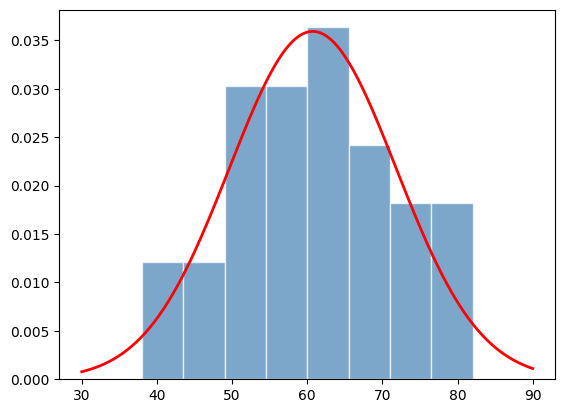

In [11]:
datos = [38,42,45,47,50,51,52,53,54,55,
         56,57,58,59,60,61,62,63,64,65,
         66,67,68,70,72,74,75,77,79,82]

# ── a) Media y desviación estándar muestral ───────────────────────────────────
mu    = np.mean(datos)
sigma = np.std(datos, ddof=1)   # ddof=1 para desviación MUESTRAL
print(f"Media muestral:             {mu:.4f}")
print(f"Desviación estándar muestral: {sigma:.4f}")

# ── b) Histograma ─────────────────────────────────────────────────────────────
x = np.linspace(30, 90, 200)
plt.hist(datos, bins=8, density=True, color='steelblue',
         edgecolor='white', alpha=0.7)
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2)
plt.show()

## Examen Parcial Juan Muñoz 

Punto 3, 1 Hallar el parametro de la distribución, 2 cual es la proba de que tenga más de 5 defectos, 3 hallar la variabilidad de los defectos

In [12]:
datos = [8, 4 ,4 ,3 ,4 ,6 , 4 ,4 , 5 , 5 , 4 , 4 , 5 , 2 , 3 , 2 , 2 , 3 , 8 , 5]
mu = np.mean(datos)    # λ = tasa promedio de ocurrencias en el intervalo
print(f"1. Parámetro de la distribución (λ): {mu}")
k  = 5    # valor específico
print(f"2. Probabilidad de que tenga más de 5 defectos P(X > {k}): {1 - poisson.cdf(k , mu)}")
print(f"3. Variabilidad de los defectos (Varianza V(X)): {mu}")


1. Parámetro de la distribución (λ): 4.25
2. Probabilidad de que tenga más de 5 defectos P(X > 5): 0.25506094762209175
3. Variabilidad de los defectos (Varianza V(X)): 4.25


Punto 4 Sea X la distancoa ..., suponga que las ratas X tiene una distribución exponencial con media 72.15, 1 determinar el parámetro de la distribucion, 2 cual es la proba de que la distancia sea como mucho 100m, cuando mucho 200 y entre 100 y 200 3 cual es la proba de que la existencia exceda la distancia media por más de 2 desviaciones estándar

In [13]:
media = 72.15
lam = 1 / media
print(f"1. Parámetro de la distribución (λ): {lam:.5f}")
p_100 = expon.cdf(100, scale=media)
p_200 = expon.cdf(200, scale=media)
print(f"2. Probabilidad de que sea como mucho 100m P(X <= 100): {p_100:.5f}")
print(f"2. Probabilidad de que sea cuando mucho 200m P(X <= 200): {p_200:.5f}")
print(f"2. Probabilidad de que esté entre 100 y 200m P(100 <= X <= 200): {p_200 - p_100:.5f}")
limit = media + 2 * media
p_excede = 1 - expon.cdf(limit, scale=media)
print(f"3. Probabilidad de que exceda la media por más de 2 desviaciones estándar P(X > {limit:.2f}): {p_excede:.5f}")


1. Parámetro de la distribución (λ): 0.01386
2. Probabilidad de que sea como mucho 100m P(X <= 100): 0.74993
2. Probabilidad de que sea cuando mucho 200m P(X <= 200): 0.93746
2. Probabilidad de que esté entre 100 y 200m P(100 <= X <= 200): 0.18754
3. Probabilidad de que exceda la media por más de 2 desviaciones estándar P(X > 216.45): 0.04979


Punto 5 1 Determinar si los datos siguen una distribución normal, justificar 2 Cuál es la probabilidad de que la concentración sea igual, menor y como mucho 105, 3 cuál es la probabilidad dee que difiera de la media por más de una desviación estandar,  4 como caracterizaría el 0.1 porciento más extremo de los valores de concentración de cloruro

1. Determinar si los datos siguen una distribución normal:
Estadístico de Shapiro-Wilk: 0.9831, p-valor: 0.9001
Justificación: p-valor > 0.05, no se rechaza la hipótesis nula. Siguen una distribución normal.

2. Probabilidad de que la concentración sea:
 - Igual a 105: 0.0000 (probabilidad puntual es cero. Densidad: 0.0679)
 - Menor o como mucho 105 P(X <= 105): 0.5480

3. Probabilidad de que difiera de la media por más de una desviación estándar:
 P(|X - mu| > sigma) = 0.3173

4. Caracterizar el 0.1% más extremo:
 Valores menores a 85.10 y mayores a 123.49.



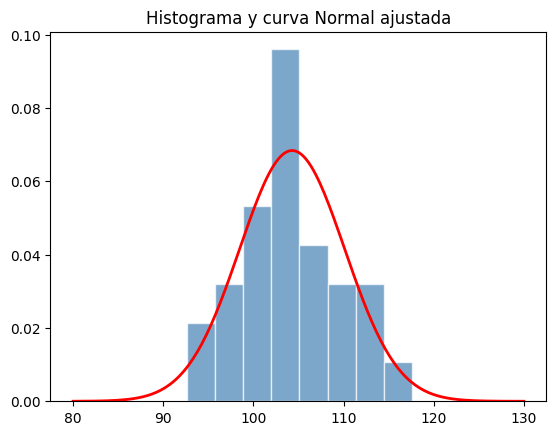

In [14]:
datos = [104.3 , 100.9 , 99.0 , 105.0 , 113.8 , 105.8 , 
         102.2 , 103.9 , 98.5 , 110.2 , 94.5 , 103.7 , 
         92.6 , 100.3 , 107.4 , 105.0 , 101.6 , 98.5 , 
         105.3 , 117.6 , 113.0 , 111.3 , 105.6 , 112.0 , 
         104.0 , 102.5 , 104.5 , 109.7 , 96.1 , 100.1]

mu    = np.mean(datos)
sigma = np.std(datos, ddof=1)   

print("1. Determinar si los datos siguen una distribución normal:")
stat, p_value = stats.shapiro(datos)
print(f"Estadístico de Shapiro-Wilk: {stat:.4f}, p-valor: {p_value:.4f}")
if p_value > 0.05:
    print("Justificación: p-valor > 0.05, no se rechaza la hipótesis nula. Siguen una distribución normal.\n")
else:
    print("Justificación: p-valor <= 0.05, se rechaza la hipótesis nula. No siguen una distribución normal.\n")

print("2. Probabilidad de que la concentración sea:")
print(f" - Igual a 105: 0.0000 (probabilidad puntual es cero. Densidad: {norm.pdf(105, mu, sigma):.4f})")
p_menor = norm.cdf(105, mu, sigma)
print(f" - Menor o como mucho 105 P(X <= 105): {p_menor:.4f}\n")

print("3. Probabilidad de que difiera de la media por más de una desviación estándar:")
dif_std = 2 * norm.cdf(mu - sigma, mu, sigma)
print(f" P(|X - mu| > sigma) = {dif_std:.4f}\n")

print("4. Caracterizar el 0.1% más extremo:")
lim_inf = norm.ppf(0.0005, mu, sigma)
lim_sup = norm.ppf(0.9995, mu, sigma)
print(f" Valores menores a {lim_inf:.2f} y mayores a {lim_sup:.2f}.\n")

x = np.linspace(80, 130, 200)
plt.hist(datos, bins=8, density=True, color='steelblue', edgecolor='white', alpha=0.7)
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2)
plt.title("Histograma y curva Normal ajustada")
plt.show()
